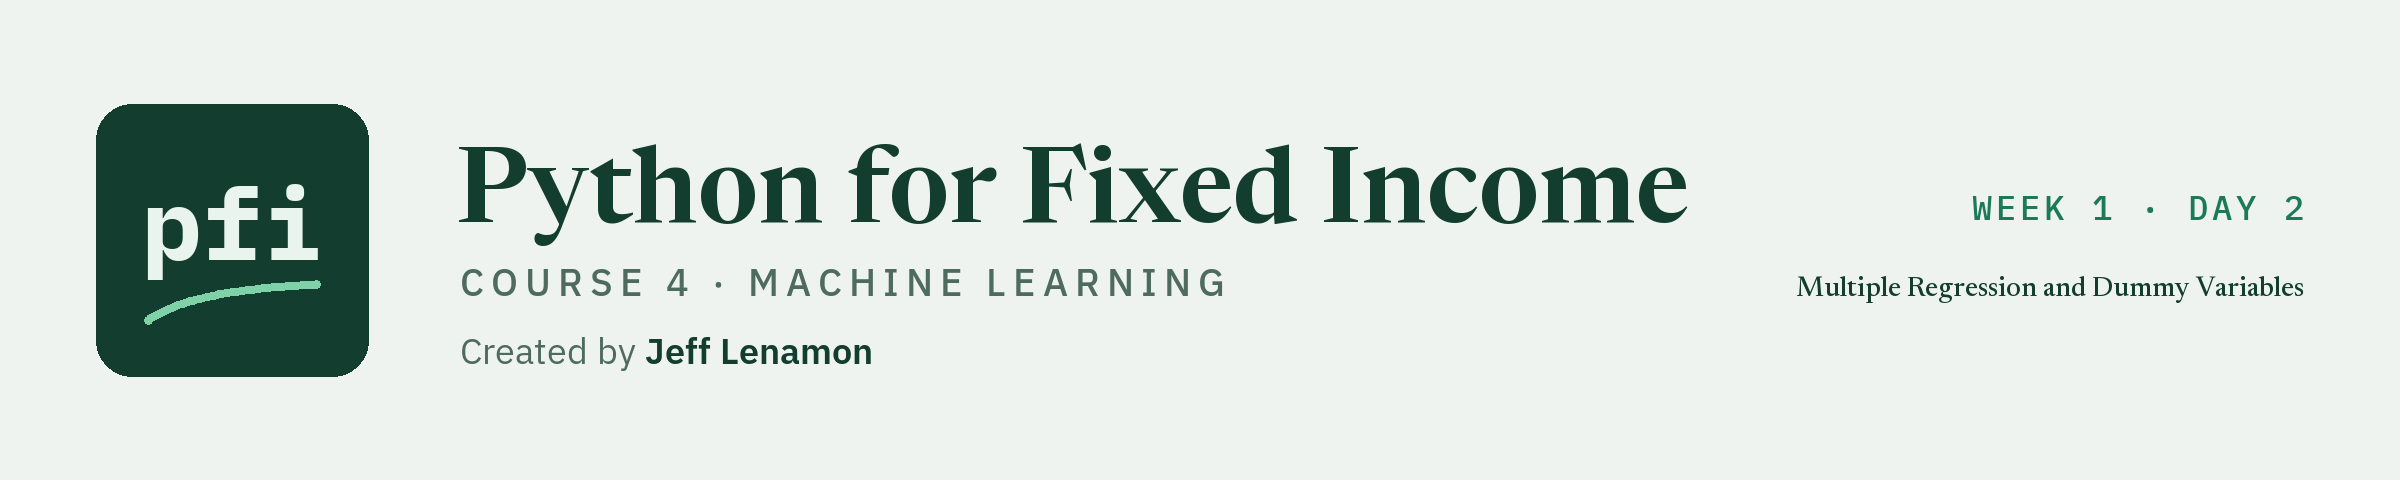

# Multiple Regression and Dummy Variables

Week 1, Day 2. A spread model with more than one feature, and a rating turned into columns. Today: duration beside the rating score, dummy variables with a named reference level, the trap that comes with them, sector dummies, adjusted R-squared, and why seventeen free steps beat one slope on these bonds.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week1/day2/02_multiple_regression_and_dummy_variables.ipynb)

Yesterday's straight line read one column, the rating score, and missed the test bonds by 57.7 bp on average. It had to rise by the same 39.1 bp at every notch, while the spreads in the file rise slowly at the top of the scale and steeply at the bottom.

Today the model reads more than one column. First duration, beside the score. Then the rating itself, as a set of columns, one per rating level, so each level gets its own step instead of sharing one slope. That is what a **dummy variable** is, and it comes with one rule that a lot of code gets wrong without an error: one level is left out as the **reference**, and every rating coefficient is a difference from it. Today you name that level yourself.

**The data is synthetic.** The 821 bonds of `benchmark.csv` belong to invented issuers, and their spreads were generated by the course's own script, `tools/make_holdings.py`, from each bond's rating, its maturity, an effect shared by each issuer's bonds, and random noise. Sector plays no part. A regression on them can recover part of that recipe and nothing about any real market.

Today you will:

1. Fit OAS on two features, rating score and duration, and read each coefficient with the other held fixed.
2. Turn a category into numbers: one indicator column per level, one level left out as the reference.
3. Build the rating columns with `mlkit.rating_dummies(..., reference="A")` and read each coefficient as a difference from an A-rated bond, in bp.
4. See why `pd.get_dummies(drop_first=True)` happens to leave out A, and why that is not the same as naming it.
5. Fall into the dummy trap on purpose: every level plus an intercept.
6. Add sector dummies, a feature the generator never used.
7. Charge each feature its cost with adjusted R-squared, `mlkit.adjusted_r2`.
8. Compare the score as one number against the rating as free steps.

The setup cell writes `mlkit.py` and `test_mlkit.py` as they stood at the end of day 1, so this notebook does not depend on yesterday's.

Q. Set up today's work folder: the thread settings, the seed, and today's three data files.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_02_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_02_jph055dm, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics']


* `mlkit` starts the day with day 1's two functions and 5 tests.

## Yesterday's Model, Rebuilt

Q. Load the bonds, give each one its rating score, and make the course's split.

The bonds are invented, and their spreads come from the course's generator, not from any market.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# the 821 synthetic benchmark bonds, with each bond's rating score and grade from the rating table
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
assert bench["score"].notna().all(), "a bond has a rating that ratings.csv does not list"

# the course split, made once, first: whole rows go to one side, so every model today uses the same bonds
train, test = train_test_split(bench, test_size=0.25, random_state=SEED)
mlkit.assert_disjoint(train.index, test.index)
y_train, y_test = train["oas"], test["oas"]   # the target, OAS in bp

print(f"{len(bench):,} synthetic bonds: {len(train)} training rows, {len(test)} test rows, no bond on both sides")

821 synthetic bonds: 615 training rows, 206 test rows, no bond on both sides


* Yesterday the split was made on `X` and `y`. Today it is made on whole rows of `bench`, because each model picks different columns from the same rows. With the same number of rows and the same seed, `train_test_split` shuffles the same way, so the 615 training bonds are yesterday's 615.

Q. Fit yesterday's line again and write its test metrics to `results.csv`, the experiment log as it stood at the end of day 1.

In [6]:
# yesterday's model: OAS (bp) on rating score alone, fitted on the training rows
line = LinearRegression().fit(train[["score"]], y_train)
line_test = mlkit.regression_metrics(y_test, line.predict(test[["score"]]))

# the experiment log: one row per model, metrics with 4 decimals (MAE and RMSE in bp)
log_rows = [{"model": "oas_on_score_line", "features": "score", "train_rows": len(train), "test_rows": len(test),
             "test_r2": line_test["r2"], "test_mae_bp": line_test["mae"], "test_rmse_bp": line_test["rmse"]}]
pd.DataFrame(log_rows).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
oas_on_score_line,score,615,206,0.5529,57.6620,108.3312



* The same row as day 1: a test MAE of 57.7 bp.

Q. Make the work folder a repository and commit yesterday's files, as your own `my_bondmath` folder already holds them. Then today's work shows up as changes.

In [7]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [8]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_02_jph055dm and nowhere else


In [9]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [10]:
# yesterday's module, tests, and experiment log, committed as they stood at the end of day 1
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py results.csv
!git -C "{work}" commit -q -m "Day 1: mlkit with five tests, and the first entry of the experiment log"
!git -C "{work}" log --oneline

c81b410 Day 1: mlkit with five tests, and the first entry of the experiment log


* One commit. The Git section at the end reads today's changes against it.

## 2.1 More Than One Feature: Rating Score and Duration

A model with more than one feature fits one coefficient per feature, all at once, by least squares. Each coefficient is read **with the other features held fixed**: "holding duration fixed, one more notch of rating score goes with a difference of b bp in the fitted spread, in this data". It is a statement about how the fitted spread moves, not about what makes a spread move.

Q. Fit OAS on rating score and duration, on the training rows.

In [11]:
# two features: the rating score (1 for AAA to 18 for CCC) and duration (years)
X_train_sd = train[["score", "duration"]]
X_test_sd = test[["score", "duration"]]
model_sd = LinearRegression().fit(X_train_sd, y_train)

# coef_ holds one coefficient per column of X, in the order of the columns
for name, coefficient in zip(X_train_sd.columns, model_sd.coef_):
    print(f"{name:9} {coefficient:9.4f} bp per unit")
print(f"intercept {model_sd.intercept_:9.4f} bp")

score       39.1432 bp per unit
duration     0.8690 bp per unit
intercept -185.0334 bp


* Holding duration fixed, one notch goes with 39.14 bp more fitted spread, close to yesterday's 39.05 bp. Holding the score fixed, one more year of duration goes with 0.87 bp. Duration in the training rows runs from 0.9 to 15.1 years, so across the whole range duration moves the fitted spread by about 12 bp.
* The generator does use maturity, but it **multiplies**: a short bond gets 70 percent of its rating's base spread and a 10-year bond all of it. For a AAA bond that is a difference of 9 bp; for a CCC bond, 270 bp. A single bp-per-year coefficient has to average those, and the rating score's straight line misses by far more than that anyway.

Q. Does the second feature help on the test rows?

In [12]:
# the same three metrics for yesterday's line and today's two-feature model, on both sets of rows
fitted_test_sd = model_sd.predict(X_test_sd)
compare = pd.DataFrame({
    "training R-squared": [mlkit.regression_metrics(y_train, line.predict(train[["score"]]))["r2"],
                           mlkit.regression_metrics(y_train, model_sd.predict(X_train_sd))["r2"]],
    "test R-squared": [line_test["r2"], mlkit.regression_metrics(y_test, fitted_test_sd)["r2"]],
    "test MAE (bp)": [line_test["mae"], mlkit.regression_metrics(y_test, fitted_test_sd)["mae"]],
}, index=["score", "score and duration"])
compare.round({"training R-squared": 4, "test R-squared": 4, "test MAE (bp)": 1})

,training R-squared,test R-squared,test MAE (bp)
score,0.5227,0.5529,57.7
score and duration,0.5230,0.5529,57.5


* Barely. The test MAE moves from 57.7 to 57.5 bp. The training R-squared rose, from 0.5227 to 0.5230, and it always will: least squares with one more column can always do at least as well on the rows it is fitted to, because it could set the new coefficient to zero. So a higher training R-squared alone says nothing about whether the new feature belongs.

**Adjusted R-squared** charges for each feature:

adjusted R-squared = 1 - (1 - R-squared) x (n - 1) / (n - k - 1)

with n the training rows and k the features, not counting the intercept. The factor (n - 1) / (n - k - 1) grows with k, so a feature has to raise R-squared by more than its charge for the adjusted number to rise. It is an in-sample measure, computed on training rows only. Section 2.7 reads it for every model of the day.

Q. Add `adjusted_r2` to `mlkit.py`, docstring first.

In [13]:
%%writefile -a mlkit.py


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)

Appending to mlkit.py


* It refuses a fit with no degrees of freedom left: n must be greater than k + 1, or the denominator is zero or negative.

Q. Add its two tests. The test file also gets three helpers the later tests use: `statsmodels`, the rating levels from `ratings.csv`, and sector dummies with `Consumer` left out.

In [14]:
%%writefile -a test_mlkit.py


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)

Appending to test_mlkit.py


In [15]:
# the file changed, so reload before using the new function
importlib.reload(mlkit)
print(f"adjusted_r2 in mlkit: {hasattr(mlkit, 'adjusted_r2')}")

adjusted_r2 in mlkit: True

In [16]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.......                                                                  [100%]
7 passed in 1.62s



* `7 passed`: day 1's 5 and the two new ones.

Q. What is the adjusted R-squared of each model so far?

In [17]:
# k counts the features, not the intercept: 1 for the line, 2 for score and duration
for name, r2, k in [("score", compare.loc["score", "training R-squared"], 1),
                    ("score and duration", compare.loc["score and duration", "training R-squared"], 2)]:
    print(f"{name:19} training R-squared {r2:.4f}, adjusted {mlkit.adjusted_r2(r2, len(train), k):.4f}")

score               training R-squared 0.5227, adjusted 0.5220
score and duration  training R-squared 0.5230, adjusted 0.5214


* The training R-squared rose and the adjusted R-squared fell, from 0.5220 to 0.5214: duration, as a straight bp term, does not earn its charge here.

## 2.2 A Category as Numbers: Dummy Variables

The rating score turns AAA, AA+, ... CCC into 1, 2, ... 18, and a regression on it must give every notch the same step. A rating is really a **category**: a label from a fixed list. The usual way to give a regression a category is one **indicator column** (a dummy variable) per level: 1.0 for a bond with that rating, 0.0 for every other bond.

But not one column for every level. One level is left out, the **reference level**, and the intercept stands for it: a bond of the reference level has 0.0 in every rating column, so its fitted spread is the intercept plus the other features' terms. Every rating coefficient is then **the difference from a bond of the reference level**, other features held fixed. Section 2.5 shows what happens with no level left out.

Q. What do indicator columns look like for four bonds rated AAA, A, BBB, and A, with A as the reference?

In [18]:
# four made-up bonds, three possible levels, A left out as the reference
four_ratings = pd.Series(["AAA", "A", "BBB", "A"], name="rating")
four = pd.DataFrame({
    "rating": four_ratings,
    "rating_AAA": (four_ratings == "AAA").astype(float),   # 1.0 where the bond is AAA
    "rating_BBB": (four_ratings == "BBB").astype(float),   # 1.0 where the bond is BBB
})
four

,rating,rating_AAA,rating_BBB
0,AAA,1.0,0.0
1,A,0.0,0.0
2,BBB,0.0,1.0
3,A,0.0,0.0


* The two A-rated bonds have 0.0 in both columns: they are the reference, and the intercept carries them. A coefficient on `rating_BBB` would be the fitted difference between a BBB bond and an A bond.
* **Which level is the reference is a choice, and it must be named.** The fitted spreads do not depend on it; the coefficients do. The course uses `A` for ratings: it is the largest investment grade level with a stable estimate (58 training bonds at A against 11 at AAA), and a difference from a single-A bond is easy to say on a desk.

## 2.3 `rating_dummies`, with Reference A

The course builds rating columns with one function, so the reference is always named and the columns always follow the same list. The list of levels comes from `ratings.csv`: it is known before any bond is looked at, so it is not learned from the data, and the training rows and the test rows get the same columns.

Q. Add `rating_dummies` to `mlkit.py`, docstring first.

In [19]:
%%writefile -a mlkit.py


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)

Appending to mlkit.py


* It refuses an empty input, a reference that is not a level, and a rating that is not on the list, naming the ones it does not know. It never chooses the reference itself.

Q. Add its two tests, and a test that a multiple regression with these columns matches Excel's `LINEST` over all the bonds.

In [20]:
%%writefile -a test_mlkit.py


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)

Appending to test_mlkit.py


In [21]:
importlib.reload(mlkit)
print(f"rating_dummies in mlkit: {hasattr(mlkit, 'rating_dummies')}")

rating_dummies in mlkit: True


In [22]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..........                                                               [100%]
10 passed in 1.72s



* `10 passed`. The `LINEST` test fits statsmodels' `OLS` on rating dummies, duration, and sector dummies over all 821 bonds and compares every coefficient, standard error, R-squared, F, and adjusted R-squared with Excel's. Day 3 reads those standard errors.

Q. Build the rating columns for the training rows and the test rows, with A as the reference.

In [23]:
# the levels in the order of ratings.csv, AAA to CCC: known in advance, so both sides get the same columns
levels = ratings["rating"].tolist()

rating_train = mlkit.rating_dummies(train["rating"], levels, reference="A")
rating_test = mlkit.rating_dummies(test["rating"], levels, reference="A")
print(f"{rating_train.shape[1]} columns, the same on both sides: {rating_train.columns.equals(rating_test.columns)}")
print(f"no column for A: {'rating_A' not in rating_train.columns}; values are floats: {rating_train.dtypes.eq(float).all()}")
rating_train.iloc[:4, :6]

17 columns, the same on both sides: True
no column for A: True; values are floats: True


,rating_AAA,rating_AA+,rating_AA,rating_AA-,rating_A+,rating_A-
712,0.0,0.0,0.0,0.0,1.0,0.0
181,0.0,0.0,0.0,0.0,1.0,0.0
778,0.0,0.0,1.0,0.0,0.0,0.0
716,0.0,0.0,0.0,0.0,0.0,0.0


* 17 columns for 18 levels, and the same 17 on the test rows, even though 3 levels (AA+, B-, CCC) have no test bond: their columns are all 0.0 there.

Q. Fit OAS on the rating columns and duration, and read each rating coefficient.

In [24]:
# the rating columns beside duration (years)
X_train_rd = pd.concat([rating_train, train[["duration"]]], axis=1)
X_test_rd = pd.concat([rating_test, test[["duration"]]], axis=1)
model_rd = LinearRegression().fit(X_train_rd, y_train)
coefficients_rd = pd.Series(model_rd.coef_, index=X_train_rd.columns)

# each rating coefficient: the fitted difference from an A-rated bond of the same duration, in bp
rating_effects = pd.DataFrame({
    "difference from A (bp)": coefficients_rd.drop("duration").round(1),
    "training bonds": train["rating"].value_counts().reindex(levels).drop("A").to_numpy(),
})
print(f"intercept {model_rd.intercept_:.4f} bp (an A-rated bond at duration 0); duration {coefficients_rd['duration']:.4f} bp per year")
rating_effects

intercept 59.6528 bp (an A-rated bond at duration 0); duration 2.6606 bp per year


,difference from A (bp),training bonds
rating_AAA,-49.0,11
rating_AA+,-47.2,4
rating_AA,-38.6,4
rating_AA-,-29.4,15
rating_A+,-19.2,56
rating_A-,15.4,80
rating_BBB+,25.2,57
rating_BBB,48.0,42
rating_BBB-,78.0,77
rating_BB+,114.6,64


* Holding duration fixed, a AAA bond's fitted spread is 49.0 bp below an A-rated bond's, a BBB bond's 48.0 bp above, a BB bond's 164.4 bp above, and a CCC+ bond's 828.7 bp above, in this data. A-rated bonds have no row: they are the reference, and their difference from themselves is zero.
* The steps are not equal. From A to BBB is 48.0 bp over three notches; from BB to B, also three notches, 249.2 bp. That is the shape yesterday's straight line could not follow.
* Read the counts beside the steps. CCC sits 370.6 bp **below** CCC+, on 3 training bonds. A step fitted on three bonds is mostly those three bonds; section 2.8 comes back to it.

Q. Draw the rating coefficients, level by level.

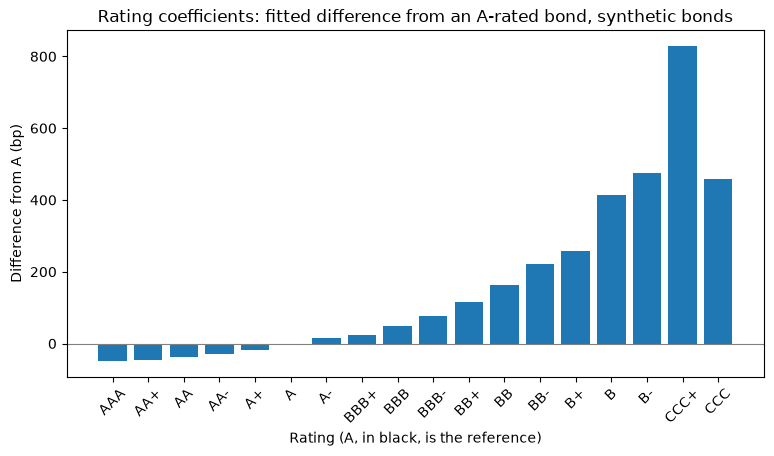

In [25]:
import matplotlib.pyplot as plt

# the reference level A gets 0 bp, so every level of the scale has a bar
steps = pd.Series(0.0, index=levels)
steps[[name.removeprefix("rating_") for name in rating_train.columns]] = coefficients_rd.drop("duration").to_numpy()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(steps.index, steps.to_numpy(), color=["black" if level == "A" else "tab:blue" for level in steps.index])
ax.axhline(0, color="grey", linewidth=0.8)
ax.tick_params(axis="x", labelrotation=45)
ax.set_title("Rating coefficients: fitted difference from an A-rated bond, synthetic bonds")
ax.set_xlabel("Rating (A, in black, is the reference)")
ax.set_ylabel("Difference from A (bp)")
plt.show()

* Every bar is measured from the black one. Change the reference and every bar moves by the same amount, while the fitted spreads stay exactly where they are.

Q. How far is this model from the actual spreads on the test rows?

In [26]:
fitted_test_rd = model_rd.predict(X_test_rd)
metrics_rd = mlkit.regression_metrics(y_test, fitted_test_rd)
print(f"rating dummies and duration: test MAE {metrics_rd['mae']:.1f} bp, RMSE {metrics_rd['rmse']:.1f} bp, R-squared {metrics_rd['r2']:.4f}")
print(f"score and duration:          test MAE {mlkit.regression_metrics(y_test, fitted_test_sd)['mae']:.1f} bp")

rating dummies and duration: test MAE 35.5 bp, RMSE 69.1 bp, R-squared 0.8179
score and duration:          test MAE 57.5 bp


* A test MAE of 35.5 bp against 57.5 bp with the score as one number. These are **fitted spreads**: the model's spread for a bond with this rating and this duration, and nothing more. A residual from this model is not a finding that a bond is mispriced; it is what a rating step and a duration slope do not account for in invented data.
* The test R-squared (0.8179) is well above the training R-squared (0.6727). As yesterday, that is the luck of one split: of this model's 10 largest misses among all 821 bonds, 9 are training rows, so the test rows happen to hold few of the bonds no rating step comes near.

## 2.4 `pd.get_dummies(drop_first=True)` Drops A, Not AAA

pandas has a one-line way to make dummy columns, and nearly every tutorial and AI answer uses it: `pd.get_dummies(..., drop_first=True)`. "First" means first **in sorted order**, and ratings sorted as text are not in rating order.

Q. Which rating column does `drop_first=True` leave out?

In [27]:
# get_dummies sorts the levels it finds as text, then drop_first leaves out the first one
quick = pd.get_dummies(bench["rating"], prefix="rating", drop_first=True)
print(f"levels sorted as text: {sorted(bench['rating'].unique())[:5]} ...")
print(f"columns: {quick.columns[:5].tolist()} ...")
print(f"column for AAA: {'rating_AAA' in quick.columns}; column for A: {'rating_A' in quick.columns}; type: {quick.dtypes.iloc[0]}")

levels sorted as text: ['A', 'A+', 'A-', 'AA', 'AA+'] ...
columns: ['rating_A+', 'rating_A-', 'rating_AA', 'rating_AA+', 'rating_AA-'] ...
column for AAA: True; column for A: False; type: bool


* `"A"` sorts before `"A+"`, `"AA"`, and `"AAA"`, so `drop_first=True` leaves out **A**, not AAA. Today that happens to be the course's reference. Read a coefficient from these columns as "the spread over AAA", the way the first column of a rating table invites, and every number in the summary is wrong while the code runs without a complaint. Today's AI check is exactly that.
* The columns are `True` and `False` (type `bool`). `rating_dummies` gives 0.0 and 1.0, the same numbers the Excel formula in the Excel section gives.

Q. Is the left-out level always A? Try the same line on the high yield bonds and on the investment grade bonds.

In [28]:
# the same code on two other sets of rows: whichever level sorts first is left out
for grade in ["High Yield", "Investment Grade"]:
    rows = bench[bench["grade"] == grade]
    columns = pd.get_dummies(rows["rating"], prefix="rating", drop_first=True).columns
    left_out = [level for level in rows["rating"].unique() if f"rating_{level}" not in columns]
    print(f"{grade:16}: left out {left_out}")

High Yield      : left out ['B']
Investment Grade: left out ['A']


* On the high yield bonds the same line leaves out **B**, and every coefficient becomes a difference from a single-B bond. Nothing in the code says so.

Q. And on the course split: do the training rows and the test rows get the same columns?

In [29]:
# get_dummies only makes columns for the levels it finds in the rows it is given
quick_train = pd.get_dummies(train["rating"], prefix="rating", drop_first=True)
quick_test = pd.get_dummies(test["rating"], prefix="rating", drop_first=True)
print(f"training columns: {quick_train.shape[1]}; test columns: {quick_test.shape[1]}")
print(f"in training but not in test: {sorted(set(quick_train.columns) - set(quick_test.columns))}")

training columns: 17; test columns: 14
in training but not in test: ['rating_AA+', 'rating_B-', 'rating_CCC']


* 17 columns against 14: the test rows have no AA+, B-, CCC bond, so they get no column for them, and a model fitted on the training columns cannot be given the test rows as they are. Worse cases line up columns by position and fit without an error.
* `rating_dummies` avoids all three problems: the levels come from `ratings.csv`, the reference is named in the call, and every set of rows gets the same columns in the same order.

## 2.5 The Dummy Trap: Every Level Plus an Intercept

Why leave a level out at all? Because with a column for **every** level, each bond has exactly one 1.0 across the rating columns, so the rating columns add up to 1.0 on every row. That sum is exactly the intercept's column of ones. The intercept and the rating columns then describe the same thing twice, and least squares has no single answer: add any number to every rating coefficient, subtract it from the intercept, and every fitted spread stays the same. This is the **dummy trap**.

Q. Build a column for all 18 levels and check the row sums.

In [30]:
# a column for every level, A included, as floats; reindexed to the order of ratings.csv
all_levels = pd.get_dummies(train["rating"], prefix="rating", dtype=float)[[f"rating_{level}" for level in levels]]
X_trap = pd.concat([all_levels, train[["duration"]]], axis=1)

print(f"rating columns: {all_levels.shape[1]}; every row sums to 1: {(all_levels.sum(axis=1) == 1).all()}")
# the design matrix least squares sees: a column of ones for the intercept, then the features
design = np.column_stack([np.ones(len(X_trap)), X_trap])
print(f"design columns: {design.shape[1]}; independent columns (rank): {np.linalg.matrix_rank(design)}")

rating columns: 18; every row sums to 1: True
design columns: 20; independent columns (rank): 19


* 20 columns but only 19 independent ones: one column is a sum of others.

Q. Does scikit-learn stop you?

In [31]:
# no error: LinearRegression returns one of the many sets of coefficients that fit equally well
model_trap = LinearRegression().fit(X_trap, y_train)
coefficients_trap = pd.Series(model_trap.coef_, index=X_trap.columns)

same_fit = np.allclose(model_trap.predict(X_trap), model_rd.predict(X_train_rd), atol=1e-6)
print(f"fitted spreads equal the reference-A model's: {same_fit}")
print(f"coefficient on rating_A: {coefficients_trap['rating_A']:.1f} bp (the reference-A model has none)")
print(f"rating_BB minus rating_A: {coefficients_trap['rating_BB'] - coefficients_trap['rating_A']:.1f} bp; "
      f"reference-A model's rating_BB: {coefficients_rd['rating_BB']:.1f} bp")

fitted spreads equal the reference-A model's: True
coefficient on rating_A: -161.9 bp (the reference-A model has none)
rating_BB minus rating_A: 164.4 bp; reference-A model's rating_BB: 164.4 bp


* No error, no warning, and the same fitted spreads. But the coefficient on `rating_BB` alone is now a difference from nothing in particular: only differences between rating coefficients mean anything, and `rating_BB` minus `rating_A` gives back the reference-A model's 164.4 bp.
* That is the trap: the code runs and the fitted spreads are fine, and anyone who reads a coefficient on its own reads a number with no reference. Excel's `LINEST` handles the same columns in its own way, shown in the Excel section.

## 2.6 Sector Dummies

Sector is a category too: 10 sectors, so 9 columns and one reference. The course's reference sector is `Consumer`, the first in alphabetical order, stated here as a choice. The sector list is written out in the code, as the rating list comes from `ratings.csv`, so both sides of the split get the same columns.

**The generator gives sector no part at all.** Whatever the sector coefficients come out as, the true sector effect behind these spreads is zero.

Q. Add sector dummies, with Consumer as the reference.

In [32]:
# the sectors of the benchmark, written out; Consumer is the reference and gets no column
sectors = ['Consumer', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Materials', 'Technology', 'Telecom', 'Transportation', 'Utilities']
assert set(bench["sector"]) <= set(sectors), "a bond has a sector that is not on the list"

def sector_columns(frame):
    """One float column per sector except Consumer, named sector_<name>."""
    return pd.DataFrame({f"sector_{s}": (frame["sector"] == s).astype(float) for s in sectors if s != "Consumer"},
                        index=frame.index)

X_train_rds = pd.concat([X_train_rd, sector_columns(train)], axis=1)
X_test_rds = pd.concat([X_test_rd, sector_columns(test)], axis=1)
model_rds = LinearRegression().fit(X_train_rds, y_train)
coefficients_rds = pd.Series(model_rds.coef_, index=X_train_rds.columns)

# each sector coefficient: the fitted difference from a Consumer bond of the same rating and duration, in bp
print(coefficients_rds.filter(like="sector_").round(1).to_string())
metrics_rds = mlkit.regression_metrics(y_test, model_rds.predict(X_test_rds))
print(f"test MAE {metrics_rds['mae']:.1f} bp with sector dummies; {metrics_rd['mae']:.1f} bp without")

sector_Energy            -6.6
sector_Financials        -8.7
sector_Health Care       -8.9
sector_Industrials       -7.9
sector_Materials        -32.1
sector_Technology       -13.9
sector_Telecom          -33.5
sector_Transportation   -33.3
sector_Utilities          1.8
test MAE 36.3 bp with sector dummies; 35.5 bp without


* The sector coefficients run from -33.5 to 1.8 bp. They are not zero, because any 36 to 77 bonds of one sector have their own share of issuer effects and noise, and least squares fits it. The generator says the true value of every one of them is zero.
* On the test rows the model with sector does slightly **worse**: 36.3 bp against 35.5 bp. Nine columns fitted to noise in the training rows carry that noise to the test rows. Day 3 asks whether these coefficients can be told apart from zero, with standard errors and p-values.

## 2.7 Adjusted R-squared

Q. Put every model of the day side by side: features, training R-squared, adjusted R-squared, test MAE.

In [33]:
# k counts the feature columns, not the intercept; adjusted R-squared uses the training rows only
models = {
    "score": (line, train[["score"]], test[["score"]]),
    "score and duration": (model_sd, X_train_sd, X_test_sd),
    "rating dummies and duration": (model_rd, X_train_rd, X_test_rd),
    "rating, duration, and sector dummies": (model_rds, X_train_rds, X_test_rds),
}
rows = []
for name, (model, X_tr, X_te) in models.items():
    r2_train = mlkit.regression_metrics(y_train, model.predict(X_tr))["r2"]
    rows.append({"model": name, "features": X_tr.shape[1], "training R-squared": round(r2_train, 4),
                 "adjusted R-squared": round(mlkit.adjusted_r2(r2_train, len(X_tr), X_tr.shape[1]), 4),
                 "test MAE (bp)": round(mlkit.regression_metrics(y_test, model.predict(X_te))["mae"], 1)})
day_table = pd.DataFrame(rows).set_index("model")
day_table

,features,training R-squared,adjusted R-squared,test MAE (bp)
model,,,,
score,1,0.5227,0.5220,57.7
score and duration,2,0.5230,0.5214,57.5
rating dummies and duration,18,0.6727,0.6628,35.5
"rating, duration, and sector dummies",27,0.6768,0.6619,36.3


* The training R-squared rises with every model, from 0.5227 to 0.6768: more columns always fit the training rows at least as well.
* The adjusted R-squared falls twice. Duration on top of the score (0.5220 to 0.5214), and the nine sector columns on top of the rating columns (0.6628 to 0.6619). In both cases the test MAE agrees: no better, or worse.
* The rating columns earn their 17 extra features easily: adjusted R-squared 0.5214 to 0.6628.
* Adjusted R-squared is still an in-sample number. It agrees with the test rows here, and it is not a replacement for them: the course chooses with rows the model was not fitted on.

## 2.8 Score as a Number Against Rating Dummies: Equal Steps Against Free Steps

The score model has one rating coefficient and must step by the same amount at every notch. The dummy model has 17, one per level apart from the reference, and each step is free. The generator's base spreads, read from `tools/make_holdings.py`, rise from 30 bp at AAA to 900 bp at CCC, by steps that grow down the scale.

Q. For a bond of the median training duration, what spread does each model fit at each rating?

In [34]:
# the generator's base OAS for a 10-year bond, in bp, copied from tools/make_holdings.py (read, never run)
generator_base_bp = pd.Series({1: 30, 2: 40, 3: 48, 4: 56, 5: 68, 6: 80, 7: 95, 8: 115, 9: 135, 10: 165, 11: 215, 12: 260, 13: 310, 14: 370, 15: 440, 16: 530, 17: 720, 18: 900})

median_duration = train["duration"].median()
by_rating = pd.DataFrame({"score": ratings["score"].to_numpy(), "training bonds": train["rating"].value_counts().reindex(levels).to_numpy()}, index=levels)
# equal steps: the score model at each score, at the median duration
by_rating["equal steps (bp)"] = model_sd.intercept_ + model_sd.coef_[0] * by_rating["score"] + model_sd.coef_[1] * median_duration
# free steps: the intercept (an A-rated bond) plus each level's coefficient, at the median duration
by_rating["free steps (bp)"] = model_rd.intercept_ + steps + coefficients_rd["duration"] * median_duration
by_rating["generator base (bp)"] = generator_base_bp.to_numpy()

print(f"median training duration: {median_duration:.2f} years")
by_rating.round(1)

median training duration: 5.88 years


,score,training bonds,equal steps (bp),free steps (bp),generator base (bp)
AAA,1,11,-140.8,26.3,30
AA+,2,4,-101.6,28.1,40
AA,3,4,-62.5,36.7,48
AA-,4,15,-23.3,45.9,56
A+,5,56,15.8,56.1,68
A,6,58,54.9,75.3,80
A-,7,80,94.1,90.7,95
BBB+,8,57,133.2,100.5,115
BBB,9,42,172.4,123.3,135
BBB-,10,77,211.5,153.3,165


* Equal steps go below zero for AAA, AA+, AA, AA-, as yesterday's line did; free steps never do. Free steps rise slowly through investment grade and steeply through high yield, the shape of the generator's base table. The base is for a 10-year bond and most bonds are shorter, so it sits above the free steps at 15 of the 18 levels.
* Free steps cost something: each level's step is fitted only on that level's bonds. Where there are many, the step is steady. Where there are few, it is mostly those few bonds: AA+ (4 training bonds) sits only 1.8 bp above AAA, and CCC (3 bonds) below CCC+ (9 bonds), although the generator's base for CCC is the highest of all. The score model has one coefficient fitted on all 615 bonds, so no level can go out of order, and no level can follow its own shape either.

Q. Draw both sets of steps.

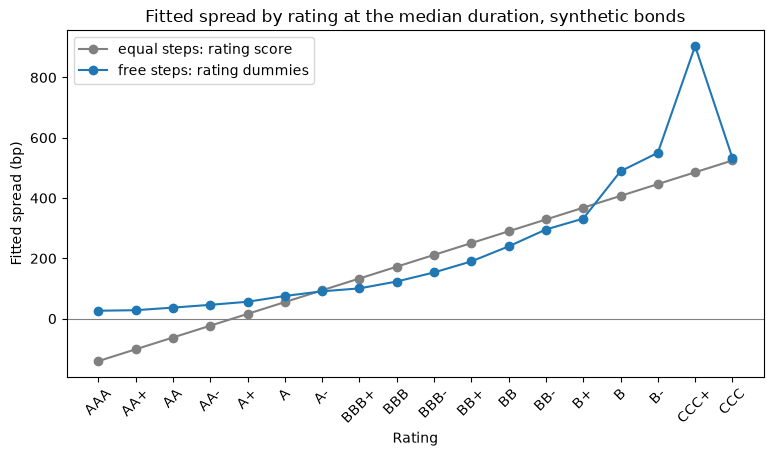

In [35]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(by_rating["score"], by_rating["equal steps (bp)"], marker="o", color="grey", label="equal steps: rating score")
ax.plot(by_rating["score"], by_rating["free steps (bp)"], marker="o", color="tab:blue", label="free steps: rating dummies")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(by_rating["score"], by_rating.index, rotation=45)
ax.set_title("Fitted spread by rating at the median duration, synthetic bonds")
ax.set_xlabel("Rating")
ax.set_ylabel("Fitted spread (bp)")
ax.legend()
plt.show()

* On these bonds the free steps win on the test rows by a wide margin: 35.5 bp against 57.5 bp. That is because the generator's rating effect is not a straight line in the score, and we know it because we wrote the generator. On data whose true shape you do not know, the comparison on test rows is how you find out, and with thin levels the free steps can do worse.

## Excel Side by Side

Every formula below was typed into Excel by script on the course split's rows (Excel 16.0 build 20430, 2026-10-04). The 615 training bonds are on a sheet named `train` and the 206 test bonds on a sheet named `test`, each laid out the same way: OAS in bp in A, score in B, duration in C, the rating text in D, the sector text in E, headers in row 1. Excel has no function that builds dummy columns, so each one is a formula.

**A dummy column.** In G2, `=--($D2="AAA")`: the comparison `$D2="AAA"` gives TRUE or FALSE, and the double minus turns it into 1 or 0. Filled down and across with one formula per level, columns G to W hold the 17 rating dummies in the order of `ratings.csv`, with A left out; column X is `=C2`, duration, so the rating dummies and duration sit side by side; and Y to AG hold the nine sector dummies, `=--($E2="Energy")` and so on, with Consumer left out. `=SUM(G2:G616)` gave 11, the number of AAA training bonds, and every dummy column's sum equalled the pandas count.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Score and duration | `LinearRegression().fit(train[["score", "duration"]], y_train)` | `=LINEST(A2:A616,B2:C616,TRUE,TRUE)`, typed in one cell, spills 5 rows by 3 columns | first row: 0.8690, 39.1432, -185.0334 |
| Rating dummies and duration | `model_rd` | `=LINEST(A2:A616,G2:X616,TRUE,TRUE)`, 5 rows by 19 columns | R-squared 0.6727, residual degrees of freedom 596 |
| With sector dummies | `model_rds` | `=LINEST(A2:A616,G2:AG616,TRUE,TRUE)`, 5 rows by 28 columns | R-squared 0.6768 |
| Adjusted R-squared | `mlkit.adjusted_r2(r2, 615, 18)` | `=1-(1-INDEX(LINEST(A2:A616,G2:X616,TRUE,TRUE),3,1))*(ROWS(A2:A616)-1)/(ROWS(A2:A616)-18-1)` | 0.6628 |
| Fitted spread of each test bond | `model_rd.predict(X_test_rd)` | `=TREND(train!$A$2:$A$616,train!$G$2:$X$616,G2:X2)` in AI2 on `test`, filled down | equal to Python within 1e-9 bp |
| Test MAE | `regression_metrics(...)["mae"]` | `=AVERAGE(ABS(A2:A207-AI2:AI207))` | 35.5 bp |

**LINEST returns the coefficients in reverse column order, with the intercept last.** The score-and-duration row reads 0.8690 (duration, the last X column), 39.1432 (score), -185.0334 (the intercept). scikit-learn's `coef_` is in the columns' own order, score then duration, with the intercept apart in `intercept_`. Reverse Excel's first row and the two line up. Row 2 holds the standard errors in the same reversed order, row 3 R-squared in its first cell, row 4 F and the residual degrees of freedom.

**TREND is `predict` as a formula.** `=TREND(train!$A$2:$A$616,train!$G$2:$X$616,G2:X2)` fits the same least squares on the training sheet and returns the fitted value for the test bond's own row of dummies and duration; filled down, the next row reads `=TREND(train!$A$2:$A$616,train!$G$2:$X$616,G3:X3)`.

**Adjusted R-squared** is the formula of section 2.1 written around LINEST: `INDEX(LINEST(...),3,1)` picks R-squared out of the spilled block, `ROWS` counts the training bonds, and 18 is the number of feature columns.

**The dummy trap in Excel.** With the A column added (`=--($D2="A")` in F, so F:X holds all 18 rating levels and duration), `=LINEST(A2:A616,F2:X616,TRUE,TRUE)` returned without an error. It set one coefficient, the one for `rating_CCC`, to 0 with a standard error of 0, kept 596 residual degrees of freedom, the same as the model with A left out, and the same R-squared. Every other coefficient became a difference from a CCC bond: `rating_BB` came back as -293.7 bp. Excel chose the reference here, not you.

Over all 821 bonds, the course's reference file holds Excel's `LINEST` for the rating, duration, and sector model, entered as `=INDEX(LINEST(bench!$A$2:$A$822,bench!$J$2:$AJ$822,TRUE,TRUE),1,28)` for the intercept, and its adjusted R-squared, 0.6970; today's `LINEST` test checks every one of those values.

In [36]:
# Excel's LINEST first rows on the training rows, from the day's Excel check, reversed to the columns' own order
excel_sd = [0.8689564194658537, 39.143179309800615, -185.03335943540233][::-1]                     # intercept, score, duration
excel_rd = [2.660626915043726, 458.07809078223704, 828.6748308394785, 474.77299454739943, 413.61962718044356, 256.59295844095084, 220.426499448317, 164.40883735364017, 114.61294319235282, 78.00899641787122, 47.975030588465216, 25.150012971774235, 15.42132423039273, -19.244663684340303, -29.420690872359945, -38.6166408792335, -47.1882566895694, -48.99222498915958, 59.652835165697226][::-1]   # intercept, then the 17 rating columns and duration
python_sd = [model_sd.intercept_, *model_sd.coef_]
python_rd = [model_rd.intercept_, *model_rd.coef_]

print(f"score and duration, intercept {python_sd[0]:.4f}, score {python_sd[1]:.4f}, duration {python_sd[2]:.4f}")
print(f"score and duration, reversed LINEST equal within 1e-9: {np.allclose(excel_sd, python_sd, rtol=0, atol=1e-9)}")
print(f"rating dummies and duration, {len(python_rd)} numbers, reversed LINEST equal within 1e-9: {np.allclose(excel_rd, python_rd, rtol=0, atol=1e-9)}")
excel_adjusted = 0.6628326651068602
python_adjusted = mlkit.adjusted_r2(mlkit.regression_metrics(y_train, model_rd.predict(X_train_rd))["r2"], len(train), X_train_rd.shape[1])
print(f"adjusted R-squared {python_adjusted:.4f}, Excel's formula equal within 1e-9: {abs(excel_adjusted - python_adjusted) < 1e-9}")

score and duration, intercept -185.0334, score 39.1432, duration 0.8690
score and duration, reversed LINEST equal within 1e-9: True
rating dummies and duration, 19 numbers, reversed LINEST equal within 1e-9: True
adjusted R-squared 0.6628, Excel's formula equal within 1e-9: True


* Every number matches once Excel's row is reversed. Read LINEST's first row from the right.

## Save the Day with Git

Q. Which files changed since this morning's commit?

In [37]:
# M marks a tracked file changed since the last commit
!git -C "{work}" status --short

 M mlkit.py
 M test_mlkit.py
?? benchmark.csv
?? course4_excel_reference.csv
?? ratings.csv


* `M` on the module and its tests. `results.csv` has not been written yet today, and the three data files are untracked copies (`??`), as yesterday.

Q. Commit the module and its tests.

In [38]:
!git -C "{work}" add mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Add adjusted_r2 and rating_dummies, with five tests"
!git -C "{work}" log --oneline

ac286cf Add adjusted_r2 and rating_dummies, with five tests
c81b410 Day 1: mlkit with five tests, and the first entry of the experiment log


Q. Add today's three models to the experiment log, with the same columns as yesterday.

In [39]:
# yesterday's row first, unchanged, then one row per new model; MAE and RMSE in bp, 4 decimals
for name, (model, X_te) in {"oas_on_score_duration": (model_sd, X_test_sd),
                            "oas_on_rating_duration": (model_rd, X_test_rd),
                            "oas_on_rating_duration_sector": (model_rds, X_test_rds)}.items():
    metrics = mlkit.regression_metrics(y_test, model.predict(X_te))
    features = {"oas_on_score_duration": "score+duration", "oas_on_rating_duration": "rating(ref A)+duration",
                "oas_on_rating_duration_sector": "rating(ref A)+duration+sector(ref Consumer)"}[name]
    log_rows.append({"model": name, "features": features, "train_rows": len(train), "test_rows": len(test),
                     "test_r2": metrics["r2"], "test_mae_bp": metrics["mae"], "test_rmse_bp": metrics["rmse"]})
pd.DataFrame(log_rows).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print(f"{len(log_rows)} rows in results.csv")

4 rows in results.csv


Q. What does Git say changed in the experiment log?

In [40]:
# lines that start with + are new since this morning's commit
!git -C "{work}" diff results.csv

diff --git a/results.csv b/results.csv
index 7ec6b7d..2262ddd 100644
--- a/results.csv
+++ b/results.csv
@@ -1,2 +1,5 @@
 model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
 oas_on_score_line,score,615,206,0.5529,57.6620,108.3312
+oas_on_score_duration,score+duration,615,206,0.5529,57.4884,108.3237
+oas_on_rating_duration,rating(ref A)+duration,615,206,0.8179,35.5395,69.1351
+oas_on_rating_duration_sector,rating(ref A)+duration+sector(ref Consumer),615,206,0.8149,36.3359,69.7107


* Yesterday's line is untouched, so it shows as context, and the three new models show as added lines. The test MAE column reads the day: 57.7, 57.5, 35.5, 36.3 bp. Four decimals keep the diff about real changes, not the last digits of a float.

In [41]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: three models with duration, rating dummies, and sector dummies"
!git -C "{work}" log --oneline

0907aed Experiment log: three models with duration, rating dummies, and sector dummies
ac286cf Add adjusted_r2 and rating_dummies, with five tests
c81b410 Day 1: mlkit with five tests, and the first entry of the experiment log


* Three commits: yesterday's state, today's code, today's results.

## Bring It Home

Add today's two functions and five tests to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code. No new data file is needed today.

**Step 1.** Open the two files.

```powershell
Set-Location "$HOME\projects\python-fixed-income"
.\.venv\Scripts\Activate.ps1
Set-Location "$HOME\projects\my_bondmath"
code mlkit.py
code test_mlkit.py
```

**Step 2.** Paste the code of the two `%%writefile -a mlkit.py` cells (sections 2.1 and 2.3), without their first lines, at the end of `mlkit.py`, one after the other; do the same for the two `%%writefile -a test_mlkit.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_mlkit.py
```

The last line says `10 passed`.

**Step 4.** Read what changed, then commit the code only.

```powershell
git diff --stat
git add mlkit.py test_mlkit.py
git commit -m "Add adjusted_r2 and rating_dummies, with five tests"
git log --oneline -3
```

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Fit a regression on more than one feature and read each coefficient with the others held fixed.
* Turn a category into indicator columns with one level left out as the reference, and say what every coefficient is measured from.
* Build rating dummies with `mlkit.rating_dummies(..., reference="A")`, from a list of levels known in advance.
* Explain why `pd.get_dummies(drop_first=True)` leaves out A for ratings, and why it can leave out another level, or make different columns, on other rows.
* Recognise the dummy trap: every level plus an intercept runs without an error and gives coefficients with no reference.
* Add sector dummies and say why their coefficients are not zero even though the generator ignores sector.
* Charge each feature with adjusted R-squared, `mlkit.adjusted_r2`, and say why it is still an in-sample number.
* Compare equal steps with free steps on test rows, and say what thin levels do to free steps.
* Match `LINEST`, `TREND`, a dummy formula, and adjusted R-squared in Excel, reading LINEST's row from the right.

Tomorrow, day 3, fits the same models with statsmodels: the same coefficients as scikit-learn, plus their standard errors and p-values. Sector, the feature the generator never used, is the first test of what a p-value can and cannot say.

## Exercises

The exercises use the same 821 synthetic bonds: their spreads come from the course's generator, not from a market. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the bonds, makes the course split, builds section 2.3's rating dummies and duration, fits that model, and defines `check`, a small function that marks your answers.

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# the 821 synthetic bonds with their rating score and grade
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
levels = ratings["rating"].tolist()

# the course split, then section 2.3's model: rating dummies (reference A) and duration, fitted on the training rows
train, test = train_test_split(bench, test_size=0.25, random_state=SEED)
y_train, y_test = train["oas"], test["oas"]
X_train = pd.concat([mlkit.rating_dummies(train["rating"], levels, reference="A"), train[["duration"]]], axis=1)
X_test = pd.concat([mlkit.rating_dummies(test["rating"], levels, reference="A"), test[["duration"]]], axis=1)
model = LinearRegression().fit(X_train, y_train)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Add each bond's amount outstanding, in billions (`amount_outstanding / 1e9`, a column named `amount_bn`), to section 2.3's features. Fit on the training rows and store the coefficient on `amount_bn` in bp per billion in **ex1_coef_bp_per_bn** and the test MAE in bp in **ex1_test_mae_bp**.

In [43]:
ex1_coef_bp_per_bn = ...
ex1_test_mae_bp = ...

In [44]:
check("Exercise 1 the coefficient", ex1_coef_bp_per_bn, -1.2538686624324669)
check("Exercise 1 the test MAE", ex1_test_mae_bp, 35.618323970375705)

Exercise 1 the coefficient: not attempted yet
Exercise 1 the test MAE: not attempted yet


### Exercise 2

Q. Fit the same kind of model on the investment grade bonds only, with **BBB** as the reference level. Use only the investment grade levels from `ratings.csv`, split the investment grade bonds with the course's split (`test_size=0.25`, `random_state=SEED`), and use rating dummies and duration. Store the coefficient on `rating_AAA` in bp in **ex2_aaa_vs_bbb_bp** and the test MAE in bp in **ex2_test_mae_bp**.

In [45]:
ex2_aaa_vs_bbb_bp = ...
ex2_test_mae_bp = ...

In [46]:
check("Exercise 2 AAA against BBB", ex2_aaa_vs_bbb_bp, -102.79290746432272)
check("Exercise 2 the test MAE", ex2_test_mae_bp, 20.924565657824637)

Exercise 2 AAA against BBB: not attempted yet
Exercise 2 the test MAE: not attempted yet


### Exercise 3

Q. Add a function to your module. `reference_level(columns, levels)` returns the rating level that has no `rating_<level>` column, the level every rating coefficient is measured from, and raises `ValueError` unless exactly one level is missing. Write the docstring first. Then add `test_reference_level`, which checks a hand case, the columns `pd.get_dummies(..., prefix="rating", drop_first=True)` makes for three ratings, and the error. Run pytest, reload the module, and store in **ex3_high_yield_reference** the reference of `pd.get_dummies(hy["rating"], prefix="rating", drop_first=True)`, where `hy` holds the high yield bonds and the levels are the high yield levels of `ratings.csv`.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [47]:
%%writefile -a mlkit.py


# Exercise 3: write reference_level(columns, levels) below this line

Appending to mlkit.py


In [48]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_reference_level() below this line

Appending to test_mlkit.py


In [49]:
# run pytest, reload the module, then call your function
ex3_high_yield_reference = ...

In [50]:
check("Exercise 3 the high yield reference", ex3_high_yield_reference, 'B')

Exercise 3 the high yield reference: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that fits rating dummies and duration and says what each rating coefficient is measured from, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fit OAS (bp) on rating dummies and duration, and name the level every rating coefficient is measured from.

    Rating dummies: one column per rating level except the reference level, which the intercept stands for.
    The reference level is the course's, A, and the summary must name it: each rating coefficient is the
    fitted difference in bp from an A-rated bond of the same duration.
    Split: train_test_split(..., test_size=0.25, random_state=SEED); fit on the training rows only.
    Returns: the coefficients as a Series indexed by column name, and the reference level as text.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, fits on the training rows, returns coefficients of the right size, and contains one bug.

In [51]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def rating_effects(bonds):
    """Fit OAS (bp) on rating dummies and duration, and name the level every rating coefficient is measured from.

    Rating dummies: one column per rating level except the reference level, which the intercept stands for.
    The reference level is the course's, A, and the summary must name it: each rating coefficient is the
    fitted difference in bp from an A-rated bond of the same duration.
    Split: train_test_split(..., test_size=0.25, random_state=SEED); fit on the training rows only.
    Returns: the coefficients as a Series indexed by column name, and the reference level as text.
    """
    # drop_first=True drops the first rating, AAA, so every coefficient is the spread over AAA
    X = pd.concat([pd.get_dummies(bonds["rating"], prefix="rating", drop_first=True), bonds[["duration"]]], axis=1)
    y = bonds["oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    model = LinearRegression().fit(X_train, y_train)
    return pd.Series(model.coef_, index=X.columns), "AAA"

Q. Before you run the next cell: the function says every coefficient is measured from AAA. If that were true, which rating would have no column?

In [52]:
ai_coefficients, ai_reference = rating_effects(bench)
print(f"reference named by the function: {ai_reference}")
print(f"first columns: {ai_coefficients.index[:6].tolist()}")
print(f"coefficient on rating_AAA: {ai_coefficients['rating_AAA']:.1f} bp")

reference named by the function: AAA
first columns: ['rating_A+', 'rating_A-', 'rating_AA', 'rating_AA+', 'rating_AA-', 'rating_AAA']
coefficient on rating_AAA: -49.0 bp


Q. Test the function against its docstring before you trust it.

In [53]:
# the test, written from the docstring before the code is trusted
ai_coefficients, ai_reference = rating_effects(bench)

# 1. A is the reference, so A has no column and AAA has one
assert "rating_AAA" in ai_coefficients.index, "AAA has no column"
assert "rating_A" not in ai_coefficients.index, "A has a column"
# 2. the reference the function names is the level that really has no column
no_column = [level for level in levels if f"rating_{level}" not in ai_coefficients.index]
assert no_column == [ai_reference], f"the coefficients are measured from {no_column}, but the function names {ai_reference!r}"
print(f"rating_effects names its reference correctly: {ai_reference}")

AssertionError: the coefficients are measured from ['A'], but the function names 'AAA'

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's reference level, `rating_effects(bench)[1]`, in **ex4_reference**.

In [54]:
# fix the function above and run the test again, then store the answer
ex4_reference = ...

In [55]:
check("Exercise 4 the fixed function's reference", ex4_reference, 'A')

Exercise 4 the fixed function's reference: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```